---
# Class 2:
# Scientific Libraries and Data Manipulation
---
Slides adapted from https://github.com/iastro-pt/IAPythonCourses/

** - Why not use basic Python?**

Originally Python was not designed for numeric computation in mind. Even now, 30 years after its debut:  
"The language comes with a large standard library that covers areas such as string processing (regular expressions, Unicode, calculating differences between files), Internet protocols (HTTP, FTP, SMTP, XML-RPC, POP, IMAP, CGI programming), software engineering (unit testing, logging, profiling, parsing Python code), and operating system interfaces (system calls, filesystems, TCP/IP sockets). Look at the table of contents for The Python Standard Library to get an idea of what’s available. A wide variety of third-party extensions are also available. Consult the Python Package Index to find packages of interest to you."  (https://docs.python.org/)

Thus, even if has built-in ** *math* ** and  ** *stats* ** libraries, they are not efficient. In this context, several scientific libraries appeared.


---
# Numpy (https://numpy.org/doc/stable/)


In [1]:
import numpy as np
print(np.__doc__[:188])


NumPy
=====

Provides
  1. An array object of arbitrary homogeneous items
  2. Fast mathematical operations over arrays
  3. Linear Algebra, Fourier Transforms, Random Number Generation





## - Why Numpy?


"NumPy is the fundamental package for scientific computing in Python. It is a Python library that provides a multidimensional array object, various derived objects (such as masked arrays and matrices), and an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulation and much more." (https://numpy.org/)

### &rarr; Example: Multiplying two lists/arrays


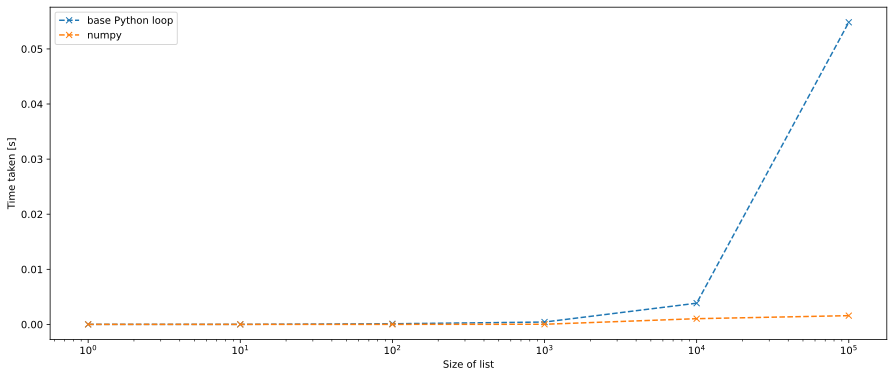

In [3]:
from time import process_time       # for timing
import matplotlib.pyplot as mplt    # for plotting

time_py_loop, time_py_comprehensive, time_numpy = [],[],[]

lengths = sorted(10**n for n in range (6))

# print (lengths)
for lenght in lengths:
    a = range (lenght)
    b = range (lenght)

    # with base Python (looping)
    start_py = process_time()
    c = []
    for i in range(len(a)):
        c.append(a[i]*b[i])
    end_py = process_time()
    time_py_loop.append(end_py - start_py)

    # with base Python (comprehensive)
    start_py = process_time()
    c = [a_i*b_i for a_i,b_i in zip(a,b)]
    end_py = process_time()
    time_py_comprehensive.append(end_py - start_py)


    # with NumPy
    a = np.arange (lenght)
    b = np.arange (lenght)

    start_np = process_time()
    c = a * b
    end_np = process_time()
    time_numpy.append(end_np - start_np)

# plotting code
%config InlineBackend.figure_format = 'svg' # Better quality plots in jupyter notebooks
mplt.figure(figsize = (15,6))
mplt.plot(lengths, time_py_loop, label = 'base Python loop', ls='--', marker="x")
# mplt.plot(lengths, time_py_comprehensive, label = 'base Python comprehensive', ls='--', marker="x")
mplt.plot(lengths, time_numpy, label = 'numpy', ls='--', marker="x")

mplt.xlabel("Size of list")
mplt.ylabel("Time taken [s]")
# mplt.ticklabel_format(style="sci", axis="x", scilimits=(0,0))
mplt.xscale("log")
mplt.legend()
mplt.show()



** NumPy is much faster than base Python!!!**

https://towardsdatascience.com/how-fast-numpy-really-is-e9111df44347


## - The core of NumPy - the **ndarray** object:

The * **ndarray** * is a multidimensional container of items of the same type and size. It has two main properties:
- *shape* - specifies the dimensions of the array, and can be specified in the form of a tuple or from lists of lists.
- *dtype* - defines the data type of the items in the array (for example, *np.int32*, *np.float64*, etc)

## - Some useful NumPy functions:
### &rarr; array creation


In [10]:
import numpy as np
# Create array from list of lists
A = np.array([[1, 2, 3], [4, 5, 6]], np.int32)
print('type = {}, shape = {}\n{}\n'.format(type(A), np.shape(A),A))

type = <class 'numpy.ndarray'>, shape = (2, 3)
[[1 2 3]
 [4 5 6]]



In [11]:
# Create empty 4 x 3 array from tuple
B = np.empty((4,3), dtype = np.float64)
print('type = {}, shape = {}\n{}\n'.format(type(B), np.shape(B),B))

type = <class 'numpy.ndarray'>, shape = (4, 3)
[[ 88.18920455  52.68591298 240.37102273]
 [ 52.67625    392.55284091  53.28998721]
 [544.73465909  55.01535889 696.91647727]
 [ 73.88231922 849.09829545 355.07625   ]]



In [76]:
# 3 x 8 array, filled with zeroes
C = np.zeros((3,8), dtype = np.float64)
print('type = {}, shape = {}\n{}\n'.format(type(C), np.shape(C),C))

type = <class 'numpy.ndarray'>, shape = (3, 8)
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [79]:
# filled with ones, same shape as C
D = np.ones_like(C)
print('type = {}, shape = {}\n{}\n'.format(type(D), np.shape(D),D))

type = <class 'numpy.ndarray'>, shape = (3, 8)
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]


In [5]:
# array that starts at 3, ends at 13, with each item separated by 2
E = np.arange(3,39,2)
print('type = {}, shape = {}\n{}\n'.format(type(E), np.shape(E),E))

type = <class 'numpy.ndarray'>, shape = (18,)
[ 3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37]



In [8]:
# array with 10 evenly spaced points, calculated over the interval [-25, 13].
F = np.linspace(-25,13, num = 10)
print('type = {}, shape = {}\n{}\n'.format(type(F), np.shape(F),F))

type = <class 'numpy.ndarray'>, shape = (10,)
[-25.         -20.77777778 -16.55555556 -12.33333333  -8.11111111
  -3.88888889   0.33333333   4.55555556   8.77777778  13.        ]


### &rarr; array manipulation:




In [8]:
# reshape array E to 3 x 6
print(E.shape)
E_3x6 = E.reshape(3,6)
print('type = {}, shape = {}'.format(type(E_3x6), np.shape(E_3x6)))
print(E_3x6)


(18,)
type = <class 'numpy.ndarray'>, shape = (3, 6)
[[ 3  5  7  9 11 13]
 [15 17 19 21 23 25]
 [27 29 31 33 35 37]]


In [10]:
# transpose E_3x6
print('type = {}, shape = {}\n{}\n'.format(type(E_3x6.T), np.shape(E_3x6.T),E_3x6.T))

type = <class 'numpy.ndarray'>, shape = (6, 3)
[[ 3 15 27]
 [ 5 17 29]
 [ 7 19 31]
 [ 9 21 33]
 [11 23 35]
 [13 25 37]]


In [11]:
# indexing
import random
for i in random.sample(range(np.shape(E_3x6)[0]),2):
    for j in random.sample(range(np.shape(E_3x6)[1]),2):
        print('E_3x6[{},{}]: \t{}'.format(i,j,E_3x6[i,j]))



E_3x6[0,2]: 	7
E_3x6[0,4]: 	11
E_3x6[1,1]: 	17
E_3x6[1,4]: 	23


In [9]:
# slicing : ARRAY[start:end:step, start:end:step, ...]
# columns 0 and 2 :
label = 'E_3x6[:,0:3:2] ='
print(E_3x6)
print(label, np.array2string(E_3x6[:,0:3:2], prefix='{} '.format(label)))
print(label, np.array2string(E_3x6[:,[0,2]], prefix='{} '.format(label)))

[[ 3  5  7  9 11 13]
 [15 17 19 21 23 25]
 [27 29 31 33 35 37]]
E_3x6[:,0:3:2] = [[ 3  7]
                  [15 19]
                  [27 31]]
E_3x6[:,0:3:2] = [[ 3  7]
                  [15 19]
                  [27 31]]


In [13]:
# row 1 : 
label = 'E_3x6[1,:] ='
print(label, E_3x6[1,:])

E_3x6[1,:] = [15 17 19 21 23 25]


In [93]:
# 2 x 2 array, starting on row 0 and column 3 : 
label = 'E_3x6[:2,3:5] ='
print(label, np.array2string(E_3x6[:2,3:5], prefix='{} '.format(label)))

E_3x6[:2,3:5] = [[ 9 11]
                 [21 23]]


In [94]:
# last 3 columns from last two rows : 
label = 'E_3x6[-2:,-3:] ='
print(label, np.array2string(E_3x6[-2:,-3:], prefix='{} '.format(label)))

E_3x6[-2:,-3:] = [[21 23 25]
                  [33 35 37]]


In [13]:
# Concatenation

print(A.shape, B.shape)
print ( np.concatenate( (A,B) ) )

(2, 3) (4, 3)
[[  1.           2.           3.        ]
 [  4.           5.           6.        ]
 [ 88.18920455  52.68591298 240.37102273]
 [ 52.67625    392.55284091  53.28998721]
 [544.73465909  55.01535889 696.91647727]
 [ 73.88231922 849.09829545 355.07625   ]]


In [99]:
# stacking
print ( np.stack( (A,B[:2,:]) ) ,'\n')

print ( np.hstack( (A,B[:2,:]) ),'\n' )

print ( np.vstack( (A,B) ) ,'\n')

[[[1.e+00 2.e+00 3.e+00]
  [4.e+00 5.e+00 6.e+00]]

 [[1.e+00 1.e+01 1.e+02]
  [1.e+03 1.e+04 1.e+05]]] 

[[1.e+00 2.e+00 3.e+00 1.e+00 1.e+01 1.e+02]
 [4.e+00 5.e+00 6.e+00 1.e+03 1.e+04 1.e+05]] 

[[1.00000e+00 2.00000e+00 3.00000e+00]
 [4.00000e+00 5.00000e+00 6.00000e+00]
 [1.00000e+00 1.00000e+01 1.00000e+02]
 [1.00000e+03 1.00000e+04 1.00000e+05]
 [2.90000e-06 2.30000e-06 8.00000e-06]
 [8.19000e-05 9.37200e-04 1.54223e-02]] 


### &rarr;  mathematical operations

Input arrays for performing arithmetic operations such as add(), subtract(), multiply(), and divide() must be either of the same shape or should conform to array broadcasting rules:
* Rule 1: If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is padded with ones on its leading (left) side.
* Rule 2: If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.
* Rule 3: If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

(https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)

In [15]:
A = np.arange(9, dtype = np.float_)
np.random.shuffle(A)

A = A.reshape(3,3) 

B = np.array([5,-7,15]) 
print(A , '= A', '\n\n',B, '= B') 



[[5. 6. 1.]
 [4. 8. 3.]
 [2. 7. 0.]] = A 

 [ 5 -7 15] = B


In [17]:
# addition/subtraction
print (np.add(A,B),' = A + B\n')
print(A + B)
print (np.subtract(A,B),'= A - B')


[[10. -1. 16.]
 [ 9.  1. 18.]
 [ 7.  0. 15.]]  = A + B

[[10. -1. 16.]
 [ 9.  1. 18.]
 [ 7.  0. 15.]]
[[  0.  13. -14.]
 [ -1.  15. -12.]
 [ -3.  14. -15.]] = A - B


In [106]:
# dot/cross products
print (np.dot(A,B),' = A · B\n')
print (np.dot(B,A),' = B · A\n')

print (np.cross(A,B),' = A × B\n')
print (np.cross(B,A),' = B × A\n')

[101.  23.  62.]  = A · B

[ 75.  88. 101.]  = B · A

[[161. -50. -77.]
 [ 29.  10.  -5.]
 [ 95. -20. -41.]]  = A × B

[[-161.   50.   77.]
 [ -29.  -10.    5.]
 [ -95.   20.   41.]]  = B × A


In [21]:
# element-wise multiplication / division
print (np.multiply(A,B),' = [A_i,j · B_i,j]\n')    

print (np.divide(A,B),' = [A_i,j / B_i,j]\n')

[[ 10. -21. 105.]
 [ 40.  -7.  60.]
 [ 25.  -0.  90.]]  = [A_i,j · B_i,j]

[[ 0.4        -0.42857143  0.46666667]
 [ 1.6        -0.14285714  0.26666667]
 [ 1.         -0.          0.4       ]]  = [A_i,j / B_i,j]


https://www.tutorialspoint.com/numpy/numpy_arithmetic_operations.htm

### &rarr; statistics


In [22]:
# median
print(E_3x6)
print('{} {}'.format('np.median(E_3x6)',np.median(E_3x6, axis=1)))
# mean 
print('{:17s} = {:>6.3f}'.format('np.mean(E_3x6)',np.mean(E_3x6)))
# standart deviation
print('{:17s} = {:>6.3f}'.format('np.std(E_3x6)',np.std(E_3x6)))
# max
print('{:17s} = {:>6.3f}'.format('np.max(E_3x6)',np.max(E_3x6)))
# min
print('{:17s} = {:>6.3f}'.format('np.min(E_3x6)',np.min(E_3x6)))


[[ 3  5  7  9 11 13]
 [15 17 19 21 23 25]
 [27 29 31 33 35 37]]
np.median(E_3x6) [ 48 120 192]
np.mean(E_3x6)    = 20.000
np.std(E_3x6)     = 10.376
np.max(E_3x6)     = 37.000
np.min(E_3x6)     =  3.000


#### What if array has NaNs?

In [29]:
E_3x6_NaNs = E_3x6.astype(np.float64) 

        
for i in [0,2]:
    for j in [5,2]:
        E_3x6_NaNs[i,j] = np.nan
print (E_3x6_NaNs)

[[ 3.  5. nan  9. 11. nan]
 [15. 17. 19. 21. 23. 25.]
 [27. 29. nan 33. 35. nan]]


In [24]:
# median
print('{:21s} = {:>6.3f}'.format('np.median(E_3x6_NaNs)',np.median(E_3x6_NaNs)))
# mean
print('{:21s} = {:>6.3f}'.format('np.mean(E_3x6_NaNs)',np.mean(E_3x6_NaNs)))
# standart deviation
print('{:21s} = {:>6.3f}'.format('np.std(E_3x6_NaNs)',np.std(E_3x6_NaNs)))
# max
print('{:21s} = {:>6.3f}'.format('np.max(E_3x6_NaNs)',np.max(E_3x6_NaNs)))
# min
print('{:21s} = {:>6.3f}'.format('np.min(E_3x6_NaNs)',np.min(E_3x6_NaNs)))


np.median(E_3x6_NaNs) =    nan
np.mean(E_3x6_NaNs)   =    nan
np.std(E_3x6_NaNs)    =    nan
np.max(E_3x6_NaNs)    =    nan
np.min(E_3x6_NaNs)    =    nan


In [25]:
# median
print('{:24s} = {:>6.3f}'.format('np.nanmedian(E_3x6_NaNs)',np.nanmedian(E_3x6_NaNs)))
# mean
print('{:24s} = {:>6.3f}'.format('np.nanmean(E_3x6_NaNs)',np.nanmean(E_3x6_NaNs)))
# standart deviation
print('{:24s} = {:>6.3f}'.format('np.nanstd(E_3x6_NaNs)',np.nanstd(E_3x6_NaNs)))
# max
print('{:24s} = {:>6.3f}'.format('np.nanmax(E_3x6_NaNs)',np.nanmax(E_3x6_NaNs)))
# min
print('{:24s} = {:>6.3f}'.format('np.nanmin(E_3x6_NaNs)',np.nanmin(E_3x6_NaNs)))


np.nanmedian(E_3x6_NaNs) = 24.000
np.nanmean(E_3x6_NaNs)   = 22.714
np.nanstd(E_3x6_NaNs)    =  9.617
np.nanmax(E_3x6_NaNs)    = 37.000
np.nanmin(E_3x6_NaNs)    =  7.000


In [35]:
print(E_3x6)
print(np.nanargmax(E_3x6, axis=1))

[[ 3  5  7  9 11 13]
 [15 17 19 21 23 25]
 [27 29 31 33 35 37]]
[5 5 5]


### &rarr; file manipulation


In [110]:
# save array to txt file
np.savetxt('E_3x6_NaNs.txt',E_3x6_NaNs, fmt='%s,%.0f,%s,%s,%s,%s', delimiter=",")
print('E_3x6_NaNs.txt contents:')
with open('E_3x6_NaNs.txt', 'r') as f:
    print(f.read())
# load array from txt file with loadtxt
E_3x6_NaNs_loadtxt = np.loadtxt('E_3x6_NaNs.txt', dtype = 'float', delimiter=",", usecols=(0,1), skiprows=1)

print('\nnp.loadtxt')
print(E_3x6_NaNs_loadtxt,'\n')

# load array from txt file with genfromtxt: many more options!!
E_3x6_NaNs_genfromtxt = np.genfromtxt('E_3x6_NaNs.txt',dtype = (float,int,complex,bool,np.float64,float), delimiter=",")

print('np.genfromtxt')
print(E_3x6_NaNs_genfromtxt)

E_3x6_NaNs.txt contents:
nan,5,7.0,9.0,nan,13.0
15.0,17,19.0,21.0,nan,nan
27.0,29,31.0,33.0,35.0,37.0


np.loadtxt
[[nan  5.  7.  9. nan 13.]
 [15. 17. 19. 21. nan nan]
 [27. 29. 31. 33. 35. 37.]] 

np.genfromtxt
[(nan,  5,  7.+0.j, False, nan, 13.) (15., 17, 19.+0.j, False, nan, nan)
 (27., 29, 31.+0.j, False, 35., 37.)]


More file formats:  
https://numpy.org/doc/stable/reference/routines.io.html

## - Numpy cheat sheet:

https://www.dataquest.io/blog/numpy-cheat-sheet/